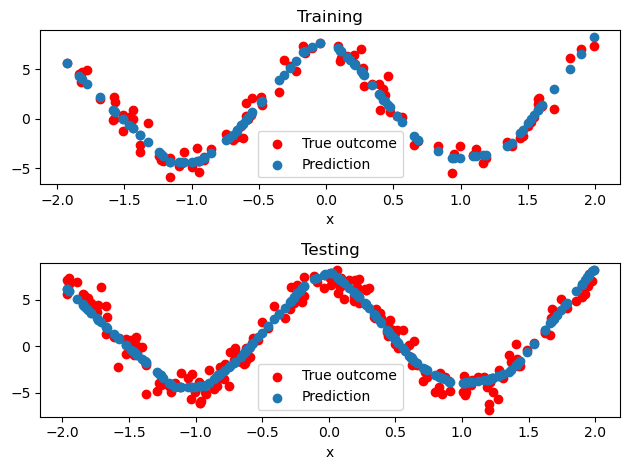

../functions/CS_sim_helper.py:154: FutureWarning: This dataframe has a column name that matches the 'value_name' column name of the resulting Dataframe. In the future this will raise an error, please set the 'value_name' parameter of DataFrame.melt to a unique name.
/Users/juntingren/opt/anaconda3/envs/deeplearning/lib/python3.7/site-packages/plotnine/ggplot.py:721: PlotnineWarning: Saving 6.4 x 4.8 in image.
/Users/juntingren/opt/anaconda3/envs/deeplearning/lib/python3.7/site-packages/plotnine/ggplot.py:722: PlotnineWarning: Filename: raw_points.jpg
/Users/juntingren/opt/anaconda3/envs/deeplearning/lib/python3.7/site-packages/plotnine/ggplot.py:721: PlotnineWarning: Saving 6.4 x 4.8 in image.
/Users/juntingren/opt/anaconda3/envs/deeplearning/lib/python3.7/site-packages/plotnine/ggplot.py:722: PlotnineWarning: Filename: CS_f.jpg


  contain contain_scb Lower_bound Upper_bound     L1   L2     U1     U2  \
0    True        True         0.6       0.955  0.775  0.6  0.955  0.975   
1    True        True         0.6        0.87  0.415  0.6   0.87   0.99   

  points_in_e1 inner_points_num outer_points_num true_set_points_num  \
0            9              160              231                 202   
1           39               89              287                 198   

                        model percent_points_FP_inner on_y  
0  <class 'models.NueralNet'>                    None    0  
1  <class 'models.NueralNet'>                    None    1  


/Users/juntingren/opt/anaconda3/envs/deeplearning/lib/python3.7/site-packages/plotnine/ggplot.py:721: PlotnineWarning: Saving 6.4 x 4.8 in image.
/Users/juntingren/opt/anaconda3/envs/deeplearning/lib/python3.7/site-packages/plotnine/ggplot.py:722: PlotnineWarning: Filename: CS_y.jpg


In [2]:
import sys
sys.path.append('../functions')
from CS_sim_helper import sim_CS,sim_CS_wrapper, generate_sim_data,check_overfitting, transform_X_poly,transform_X
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from models import NueralNet, logistic_regression
from xgboost import XGBRegressor
import torch.nn as nn
import numpy as np
models_l = [LinearRegression, RandomForestRegressor, NueralNet, XGBRegressor]
model_kwargs_l = [{},{'min_samples_leaf':6},{'input_size': 1, 'h_sizes':[40,40]}, {'n_estimators':100,'max_depth':1, 'subsample':0.7}]
# r = sim_CS(L=0.9, level = 0, models_l = models_l, model_kwargs_l = model_kwargs_l, 
#    N = 100, N_test =500, p = 1, error_sd = 1, 
#    data_sim_func = generate_sim_data, data_kwargs = {'beta':np.array([-2,2,3]),'transform_func': transform_X_poly,'uniform_range':[-2,2]},
#    center_G = True, center_pred = False, 
#    use_true_contour = False,  n_boot = 100)
# {'input_size': 4, 'h_sizes':[40,40],'out_act':'sigmoid', 'loss_fn': nn.BCELoss()}
#{'min_samples_leaf':6}
check_overfitting(model = NueralNet, model_kwargs = { 'n_iter':500,'patience':100,'input_size': 1, 'h_sizes':[40,40]}, 
          N = 100, N_test =200, p = 1, error_sd = 1, 
          data_sim_func = generate_sim_data, data_kwargs = {'transform_func':transform_X, 'beta':np.array([1,2,3,4]), 'uniform_range_x':[-2,2]})
r = sim_CS(L=0.6, level = 2, models_l = [NueralNet], model_kwargs_l = [ { 'n_iter':500,'patience':100,'input_size': 1, 'h_sizes':[40,40]}], 
   N = 100, N_test =500, p = 1, error_sd = 1, 
   data_sim_func = generate_sim_data, data_kwargs =  {'transform_func':transform_X, 'beta':np.array([1,2,3,4]),'uniform_range_x':[-2,2]},
   center_G = True, center_pred = False, 
   use_true_contour = False,  n_boot = 200, return_plot = True)
print(r)